# Bài tập cuối tuần 8: So sánh GD, SGD, Adam trên cùng một hàm

Notebook này giúp bạn thực hành so sánh 3 thuật toán tối ưu hóa:

- **GD - Gradient Descent**
- **SGD - Stochastic Gradient Descent**
- **Adam - Adaptive Moment Estimation**

Mục tiêu chính: dùng **cùng một hàm loss** để xem 3 thuật toán đi xuống điểm cực tiểu như thế nào.

> Trong AI/ML, các thuật toán này không phải dùng để “đo sai số”. Chúng dùng để **tìm bộ tham số làm loss nhỏ nhất**. Loss function đo model sai bao nhiêu; optimizer tìm cách làm loss giảm xuống.

## 1. Ý tưởng bài toán

Ta xét hàm một biến đơn giản:

$$
f(x) = (x - 3)^2 + 2
$$

Đạo hàm của hàm này là:

$$
f'(x) = 2(x - 3)
$$

Hàm đạt giá trị nhỏ nhất tại:

$$
x = 3
$$

Vì khi đó:

$$
f(3) = (3 - 3)^2 + 2 = 2
$$

Nhiệm vụ của GD, SGD, Adam là bắt đầu từ một điểm ban đầu, ví dụ `x = -5`, rồi cập nhật dần dần để tiến gần về `x = 3`.

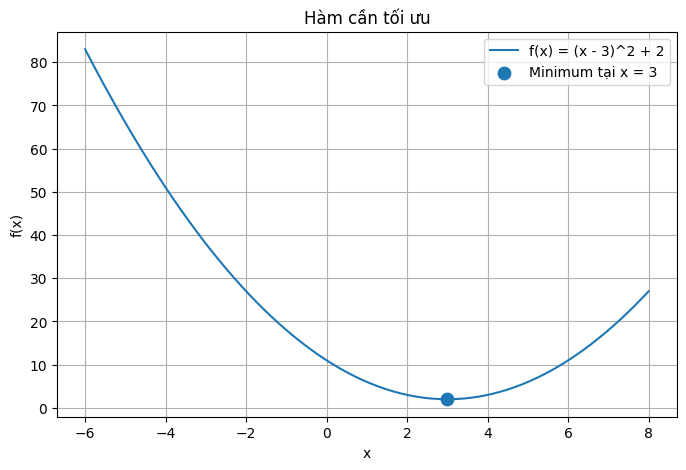

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Hàm loss cần tối ưu
def f(x):
    return (x - 3)**2 + 2

# Đạo hàm của hàm loss
def grad_f(x):
    return 2 * (x - 3)

# Vẽ hàm để nhìn trực quan
x_values = np.linspace(-6, 8, 300)
y_values = f(x_values)

plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, label='f(x) = (x - 3)^2 + 2')
plt.scatter([3], [f(3)], s=80, label='Minimum tại x = 3')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Hàm cần tối ưu')
plt.legend()
plt.grid(True)
plt.show()

## 2. Gradient Descent - GD

Công thức cập nhật của GD:

$$
x_{new} = x_{old} - learning\ rate \times gradient
$$

Với bài này:

$$
x_{new} = x_{old} - lr \times 2(x - 3)
$$

Ý nghĩa:

- Nếu `x` còn xa điểm 3, gradient lớn, bước đi lớn.
- Nếu `x` gần điểm 3, gradient nhỏ, bước đi nhỏ.
- GD đi khá ổn định vì mỗi lần cập nhật đều dùng gradient thật của toàn bộ hàm.

In [2]:
def gradient_descent(x_start, lr=0.1, epochs=50):
    x = x_start
    history = []

    for epoch in range(epochs):
        gradient = grad_f(x)
        x = x - lr * gradient
        loss = f(x)
        history.append((epoch + 1, x, loss, gradient))

    return history

history_gd = gradient_descent(x_start=-5, lr=0.1, epochs=50)

# In 10 bước đầu
for epoch, x, loss, gradient in history_gd[:10]:
    print(f"Epoch {epoch:02d}: x = {x:.4f}, loss = {loss:.4f}, gradient = {gradient:.4f}")

Epoch 01: x = -3.4000, loss = 42.9600, gradient = -16.0000
Epoch 02: x = -2.1200, loss = 28.2144, gradient = -12.8000
Epoch 03: x = -1.0960, loss = 18.7772, gradient = -10.2400
Epoch 04: x = -0.2768, loss = 12.7374, gradient = -8.1920
Epoch 05: x = 0.3786, loss = 8.8719, gradient = -6.5536
Epoch 06: x = 0.9028, loss = 6.3980, gradient = -5.2429
Epoch 07: x = 1.3223, loss = 4.8147, gradient = -4.1943
Epoch 08: x = 1.6578, loss = 3.8014, gradient = -3.3554
Epoch 09: x = 1.9263, loss = 3.1529, gradient = -2.6844
Epoch 10: x = 2.1410, loss = 2.7379, gradient = -2.1475


## 3. Stochastic Gradient Descent - SGD

Trong Machine Learning thật, SGD thường không dùng toàn bộ dữ liệu mỗi lần cập nhật. Nó dùng từng mẫu nhỏ hoặc mini-batch, nên đường đi thường **nhiễu hơn** GD.

Với bài toán hàm một biến này, ta sẽ mô phỏng SGD bằng cách thêm nhiễu vào gradient:

$$
gradient_{SGD} = gradient + noise
$$

Điều này giúp bạn thấy SGD không đi mượt như GD, nhưng vẫn có thể tiến về vùng cực tiểu.

In [3]:
def stochastic_gradient_descent(x_start, lr=0.1, epochs=50, noise_scale=1.0, seed=42):
    np.random.seed(seed)
    x = x_start
    history = []

    for epoch in range(epochs):
        true_gradient = grad_f(x)
        noise = np.random.normal(0, noise_scale)
        noisy_gradient = true_gradient + noise
        x = x - lr * noisy_gradient
        loss = f(x)
        history.append((epoch + 1, x, loss, noisy_gradient))

    return history

history_sgd = stochastic_gradient_descent(x_start=-5, lr=0.1, epochs=50, noise_scale=1.0)

for epoch, x, loss, gradient in history_sgd[:10]:
    print(f"Epoch {epoch:02d}: x = {x:.4f}, loss = {loss:.4f}, noisy_gradient = {gradient:.4f}")

Epoch 01: x = -3.4497, loss = 43.5983, noisy_gradient = -15.5033
Epoch 02: x = -2.1459, loss = 28.4804, noisy_gradient = -13.0376
Epoch 03: x = -1.1815, loss = 19.4849, noisy_gradient = -9.6441
Epoch 04: x = -0.4975, loss = 14.2325, noisy_gradient = -6.8400
Epoch 05: x = 0.2254, loss = 9.6983, noisy_gradient = -7.2292
Epoch 06: x = 0.8037, loss = 6.8235, noisy_gradient = -5.7833
Epoch 07: x = 1.0851, loss = 5.6669, noisy_gradient = -2.8133
Epoch 08: x = 1.3913, loss = 4.5879, noisy_gradient = -3.0624
Epoch 09: x = 1.7600, loss = 3.5376, noisy_gradient = -3.6868
Epoch 10: x = 1.9537, loss = 3.0947, noisy_gradient = -1.9374


## 4. Adam Optimizer

Adam cải tiến hơn GD và SGD vì nó dùng hai thông tin:

- **Momentum**: nhớ hướng đi trung bình của gradient trước đó.
- **Adaptive learning rate**: tự điều chỉnh tốc độ học theo độ lớn gradient.

Công thức Adam nhìn hơi dài, nhưng ý tưởng dễ hiểu là:

> Adam vừa nhớ hướng đi cũ, vừa tự giảm/tăng mức cập nhật cho hợp lý.

Trong thực tế Deep Learning, Adam được dùng rất phổ biến vì thường học nhanh và ổn định hơn SGD ở giai đoạn đầu.

In [4]:
def adam_optimizer(x_start, lr=0.1, epochs=50, beta1=0.9, beta2=0.999, epsilon=1e-8):
    x = x_start
    m = 0  # moment bậc 1: trung bình gradient
    v = 0  # moment bậc 2: trung bình bình phương gradient
    history = []

    for epoch in range(1, epochs + 1):
        gradient = grad_f(x)

        # Cập nhật moment
        m = beta1 * m + (1 - beta1) * gradient
        v = beta2 * v + (1 - beta2) * (gradient ** 2)

        # Bias correction
        m_hat = m / (1 - beta1 ** epoch)
        v_hat = v / (1 - beta2 ** epoch)

        # Cập nhật x
        x = x - lr * m_hat / (np.sqrt(v_hat) + epsilon)
        loss = f(x)
        history.append((epoch, x, loss, gradient))

    return history

history_adam = adam_optimizer(x_start=-5, lr=0.1, epochs=50)

for epoch, x, loss, gradient in history_adam[:10]:
    print(f"Epoch {epoch:02d}: x = {x:.4f}, loss = {loss:.4f}, gradient = {gradient:.4f}")

Epoch 01: x = -4.9000, loss = 64.4100, gradient = -16.0000
Epoch 02: x = -4.8000, loss = 62.8405, gradient = -15.8000
Epoch 03: x = -4.7001, loss = 61.2920, gradient = -15.6001
Epoch 04: x = -4.6003, loss = 59.7646, gradient = -15.4003
Epoch 05: x = -4.5006, loss = 58.2588, gradient = -15.2006
Epoch 06: x = -4.4010, loss = 56.7748, gradient = -15.0012
Epoch 07: x = -4.3016, loss = 55.3129, gradient = -14.8020
Epoch 08: x = -4.2023, loss = 53.8734, gradient = -14.6031
Epoch 09: x = -4.1033, loss = 52.4565, gradient = -14.4046
Epoch 10: x = -4.0045, loss = 51.0625, gradient = -14.2066


## 5. So sánh trực quan GD, SGD, Adam

Ta sẽ vẽ loss theo epoch của cả 3 thuật toán.

Nếu optimizer tốt, loss sẽ giảm dần về gần giá trị nhỏ nhất là `2`.

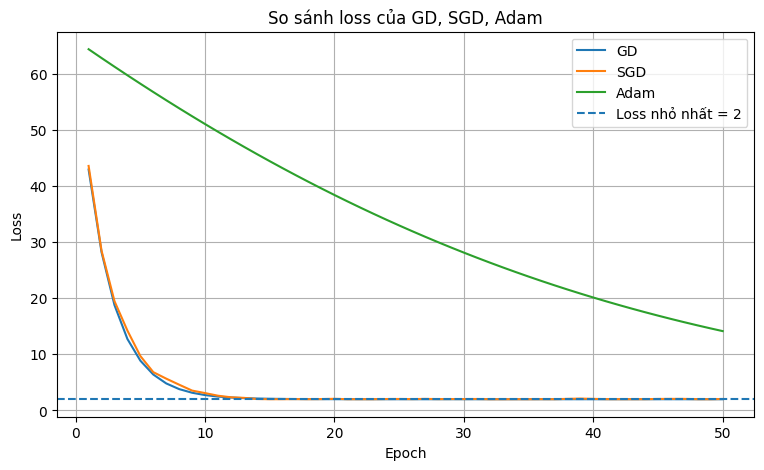

In [5]:
def get_losses(history):
    return [row[2] for row in history]

def get_x_positions(history):
    return [row[1] for row in history]

epochs = range(1, 51)

plt.figure(figsize=(9, 5))
plt.plot(epochs, get_losses(history_gd), label='GD')
plt.plot(epochs, get_losses(history_sgd), label='SGD')
plt.plot(epochs, get_losses(history_adam), label='Adam')
plt.axhline(y=2, linestyle='--', label='Loss nhỏ nhất = 2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('So sánh loss của GD, SGD, Adam')
plt.legend()
plt.grid(True)
plt.show()

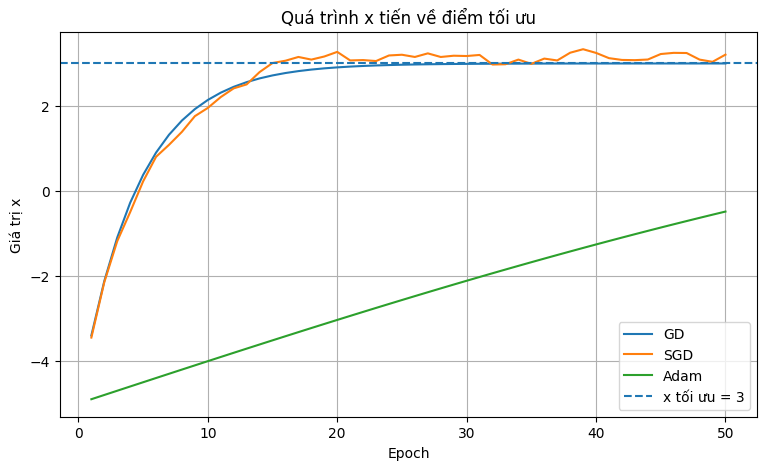

In [6]:
plt.figure(figsize=(9, 5))
plt.plot(epochs, get_x_positions(history_gd), label='GD')
plt.plot(epochs, get_x_positions(history_sgd), label='SGD')
plt.plot(epochs, get_x_positions(history_adam), label='Adam')
plt.axhline(y=3, linestyle='--', label='x tối ưu = 3')
plt.xlabel('Epoch')
plt.ylabel('Giá trị x')
plt.title('Quá trình x tiến về điểm tối ưu')
plt.legend()
plt.grid(True)
plt.show()

## 6. Bảng kết quả cuối cùng

Bảng này giúp so sánh sau 50 epochs, thuật toán nào đến gần nghiệm tối ưu hơn.

In [7]:
import pandas as pd

results = pd.DataFrame({
    'Optimizer': ['GD', 'SGD', 'Adam'],
    'Final x': [history_gd[-1][1], history_sgd[-1][1], history_adam[-1][1]],
    'Final loss': [history_gd[-1][2], history_sgd[-1][2], history_adam[-1][2]],
    'Distance to x=3': [abs(history_gd[-1][1] - 3), abs(history_sgd[-1][1] - 3), abs(history_adam[-1][1] - 3)]
})

results

,Optimizer,Final x,Final loss,Distance to x=3
0,GD,2.999886,2.000000,0.000114
1,SGD,3.206849,2.042787,0.206849
2,Adam,-0.484863,14.144273,3.484863


## 7. Nhận xét kết quả

Với hàm đơn giản này:

- **GD** thường đi rất mượt và ổn định vì gradient không bị nhiễu.
- **SGD** có đường đi dao động hơn vì gradient bị thêm nhiễu. Đây là hình ảnh gần giống khi train model bằng từng batch nhỏ.
- **Adam** thường đi nhanh lúc đầu, nhưng với learning rate chưa tối ưu, nó có thể chưa chạm đúng cực tiểu nhanh như GD trên bài toán quá đơn giản.

Kết luận quan trọng:

> Không có optimizer nào luôn thắng trong mọi tình huống. Với hàm đơn giản, GD có thể rất tốt. Với dữ liệu lớn và Deep Learning, SGD hoặc Adam thường thực tế hơn.

# Phần bài tập có lời giải

## Bài tập 1: Đổi learning rate của GD

Chạy GD với các learning rate sau:

- `lr = 0.01`
- `lr = 0.1`
- `lr = 0.5`
- `lr = 1.1`

Quan sát loss thay đổi như thế nào.

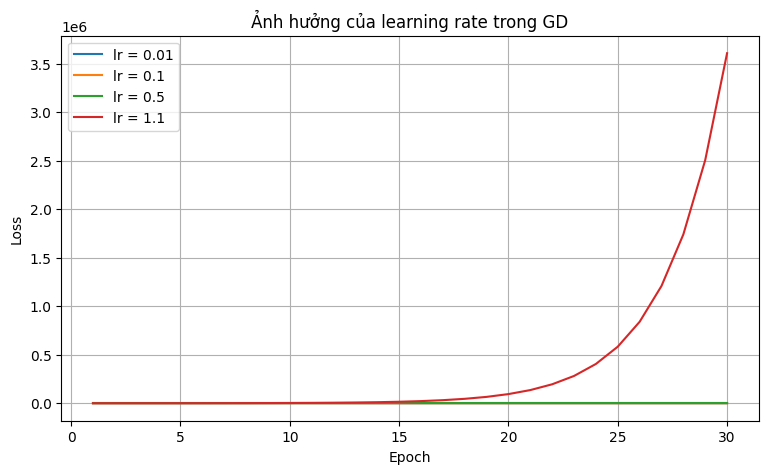

In [8]:
learning_rates = [0.01, 0.1, 0.5, 1.1]
x_start = -5
num_epochs = 30

plt.figure(figsize=(9, 5))

for lr in learning_rates:
    history = gradient_descent(x_start=x_start, lr=lr, epochs=num_epochs)
    losses = get_losses(history)
    plt.plot(range(1, num_epochs + 1), losses, label=f'lr = {lr}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Ảnh hưởng của learning rate trong GD')
plt.legend()
plt.grid(True)
plt.show()

### Giải thích bài tập 1

- `lr = 0.01`: học quá chậm, loss giảm nhưng giảm rất từ từ.
- `lr = 0.1`: học ổn định, loss giảm đều.
- `lr = 0.5`: với hàm này có thể nhảy thẳng rất nhanh về nghiệm.
- `lr = 1.1`: learning rate quá lớn, dễ làm thuật toán nhảy qua lại và loss không ổn định.

Bài học: **learning rate quá nhỏ thì học chậm, quá lớn thì dễ vượt quá điểm tối ưu**.

## Bài tập 2: So sánh SGD khi noise nhỏ và noise lớn

Chạy SGD với:

- `noise_scale = 0.2`
- `noise_scale = 1.0`
- `noise_scale = 3.0`

Mục tiêu: xem gradient nhiễu ảnh hưởng đến quá trình tối ưu như thế nào.

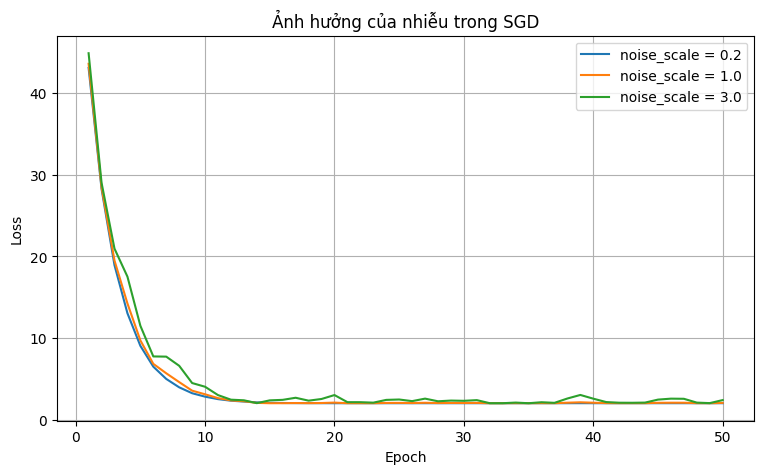

In [9]:
noise_levels = [0.2, 1.0, 3.0]

plt.figure(figsize=(9, 5))

for noise in noise_levels:
    history = stochastic_gradient_descent(
        x_start=-5,
        lr=0.1,
        epochs=50,
        noise_scale=noise,
        seed=42
    )
    plt.plot(range(1, 51), get_losses(history), label=f'noise_scale = {noise}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Ảnh hưởng của nhiễu trong SGD')
plt.legend()
plt.grid(True)
plt.show()

### Giải thích bài tập 2

- Noise nhỏ: đường đi gần giống GD, khá mượt.
- Noise vừa: loss giảm nhưng có dao động.
- Noise lớn: đường đi rung mạnh hơn, có thể lúc giảm lúc tăng.

Trong Machine Learning thật, noise xuất hiện vì SGD thường chỉ nhìn một phần dữ liệu, không nhìn toàn bộ dataset trong mỗi lần update.

## Bài tập 3: Dùng hàm khó hơn

Bây giờ đổi sang hàm:

$$
f(x) = x^4 - 3x^3 + 2
$$

Đạo hàm:

$$
f'(x) = 4x^3 - 9x^2
$$

Hàm này khó hơn vì có dạng cong phức tạp hơn hàm parabol ban đầu.

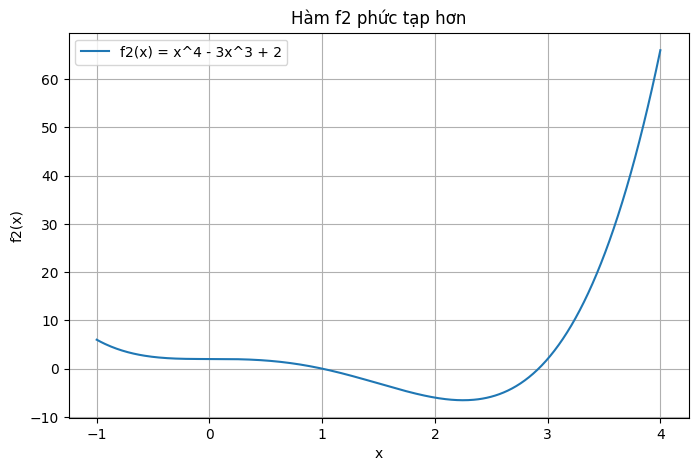

In [10]:
def f2(x):
    return x**4 - 3*x**3 + 2

def grad_f2(x):
    return 4*x**3 - 9*x**2

x_values = np.linspace(-1, 4, 400)
y_values = f2(x_values)

plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, label='f2(x) = x^4 - 3x^3 + 2')
plt.xlabel('x')
plt.ylabel('f2(x)')
plt.title('Hàm f2 phức tạp hơn')
plt.legend()
plt.grid(True)
plt.show()

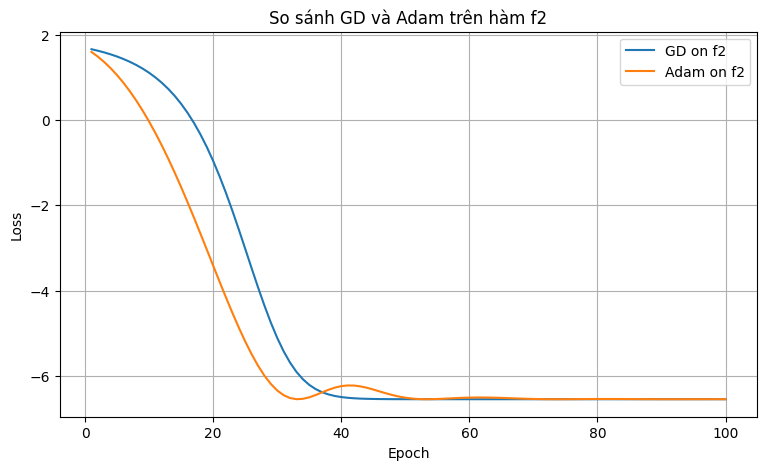

GD final: (100, 2.2499999003656757, -6.5429687499999005, -2.5298994330569258e-06)
Adam final: (100, np.float64(2.2406564610144732), np.float64(-6.542089706697766), np.float64(-0.1892911131629802))


In [11]:
def gradient_descent_custom(func, grad_func, x_start, lr=0.01, epochs=100):
    x = x_start
    history = []

    for epoch in range(epochs):
        gradient = grad_func(x)
        x = x - lr * gradient
        loss = func(x)
        history.append((epoch + 1, x, loss, gradient))

    return history

def adam_custom(func, grad_func, x_start, lr=0.05, epochs=100, beta1=0.9, beta2=0.999, epsilon=1e-8):
    x = x_start
    m = 0
    v = 0
    history = []

    for epoch in range(1, epochs + 1):
        gradient = grad_func(x)
        m = beta1 * m + (1 - beta1) * gradient
        v = beta2 * v + (1 - beta2) * gradient**2
        m_hat = m / (1 - beta1**epoch)
        v_hat = v / (1 - beta2**epoch)
        x = x - lr * m_hat / (np.sqrt(v_hat) + epsilon)
        loss = func(x)
        history.append((epoch, x, loss, gradient))

    return history

history_gd_f2 = gradient_descent_custom(f2, grad_f2, x_start=0.5, lr=0.01, epochs=100)
history_adam_f2 = adam_custom(f2, grad_f2, x_start=0.5, lr=0.05, epochs=100)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 101), get_losses(history_gd_f2), label='GD on f2')
plt.plot(range(1, 101), get_losses(history_adam_f2), label='Adam on f2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('So sánh GD và Adam trên hàm f2')
plt.legend()
plt.grid(True)
plt.show()

print('GD final:', history_gd_f2[-1])
print('Adam final:', history_adam_f2[-1])

### Giải thích bài tập 3

Với hàm khó hơn, kết quả phụ thuộc nhiều vào:

- điểm bắt đầu `x_start`
- learning rate
- hình dạng của hàm loss
- optimizer được chọn

Đây là lý do trong AI/ML, ta không chỉ chọn model mà còn phải chọn optimizer, learning rate, batch size, số epoch.

## Bài tập 4: Linear Regression bằng GD, SGD, Adam

Bài này gần với Machine Learning thật hơn.

Ta tạo dữ liệu giả lập:

$$
y = 4x + 7 + noise
$$

Model dự đoán:

$$
\hat{y} = wx + b
$$

Loss function dùng MSE:

$$
MSE = \frac{1}{n}\sum(y - \hat{y})^2
$$

Nhiệm vụ của optimizer là tìm `w` và `b` sao cho MSE nhỏ nhất.

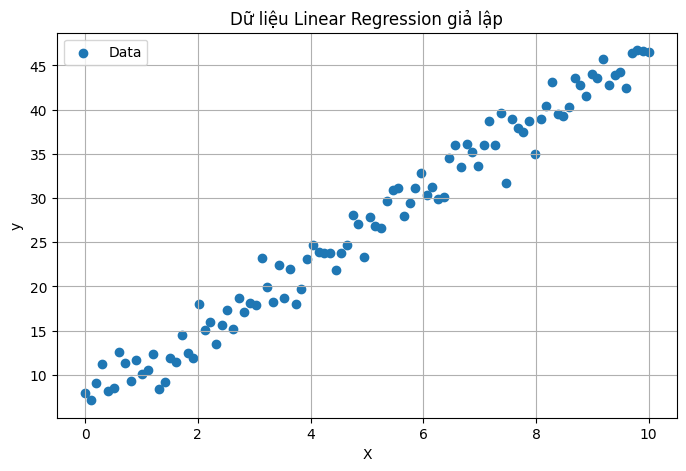

In [12]:
np.random.seed(42)

# Tạo dữ liệu giả lập
X = np.linspace(0, 10, 100)
y = 4 * X + 7 + np.random.normal(0, 2, size=len(X))

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Dữ liệu Linear Regression giả lập')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def train_linear_gd(X, y, lr=0.01, epochs=200):
    w = 0
    b = 0
    n = len(X)
    losses = []

    for epoch in range(epochs):
        y_pred = w * X + b
        loss = mse_loss(y, y_pred)
        losses.append(loss)

        dw = (-2 / n) * np.sum(X * (y - y_pred))
        db = (-2 / n) * np.sum(y - y_pred)

        w = w - lr * dw
        b = b - lr * db

    return w, b, losses

w_gd, b_gd, losses_gd = train_linear_gd(X, y, lr=0.01, epochs=200)
print(f"GD: w = {w_gd:.4f}, b = {b_gd:.4f}, final loss = {losses_gd[-1]:.4f}")

GD: w = 4.3563, b = 4.4680, final loss = 4.4850


In [14]:
def train_linear_sgd(X, y, lr=0.01, epochs=200):
    w = 0
    b = 0
    n = len(X)
    losses = []

    for epoch in range(epochs):
        indices = np.random.permutation(n)

        for i in indices:
            x_i = X[i]
            y_i = y[i]
            y_pred_i = w * x_i + b

            dw = -2 * x_i * (y_i - y_pred_i)
            db = -2 * (y_i - y_pred_i)

            w = w - lr * dw
            b = b - lr * db

        y_pred = w * X + b
        losses.append(mse_loss(y, y_pred))

    return w, b, losses

w_sgd, b_sgd, losses_sgd = train_linear_sgd(X, y, lr=0.001, epochs=200)
print(f"SGD: w = {w_sgd:.4f}, b = {b_sgd:.4f}, final loss = {losses_sgd[-1]:.4f}")

SGD: w = 4.0470, b = 6.6462, final loss = 3.2707


In [15]:
def train_linear_adam(X, y, lr=0.1, epochs=200, beta1=0.9, beta2=0.999, epsilon=1e-8):
    w = 0
    b = 0
    n = len(X)
    losses = []

    mw = 0
    vw = 0
    mb = 0
    vb = 0

    for epoch in range(1, epochs + 1):
        y_pred = w * X + b
        loss = mse_loss(y, y_pred)
        losses.append(loss)

        dw = (-2 / n) * np.sum(X * (y - y_pred))
        db = (-2 / n) * np.sum(y - y_pred)

        mw = beta1 * mw + (1 - beta1) * dw
        vw = beta2 * vw + (1 - beta2) * dw**2
        mb = beta1 * mb + (1 - beta1) * db
        vb = beta2 * vb + (1 - beta2) * db**2

        mw_hat = mw / (1 - beta1**epoch)
        vw_hat = vw / (1 - beta2**epoch)
        mb_hat = mb / (1 - beta1**epoch)
        vb_hat = vb / (1 - beta2**epoch)

        w = w - lr * mw_hat / (np.sqrt(vw_hat) + epsilon)
        b = b - lr * mb_hat / (np.sqrt(vb_hat) + epsilon)

    return w, b, losses

w_adam, b_adam, losses_adam = train_linear_adam(X, y, lr=0.1, epochs=200)
print(f"Adam: w = {w_adam:.4f}, b = {b_adam:.4f}, final loss = {losses_adam[-1]:.4f}")

Adam: w = 4.2741, b = 5.0718, final loss = 3.9027


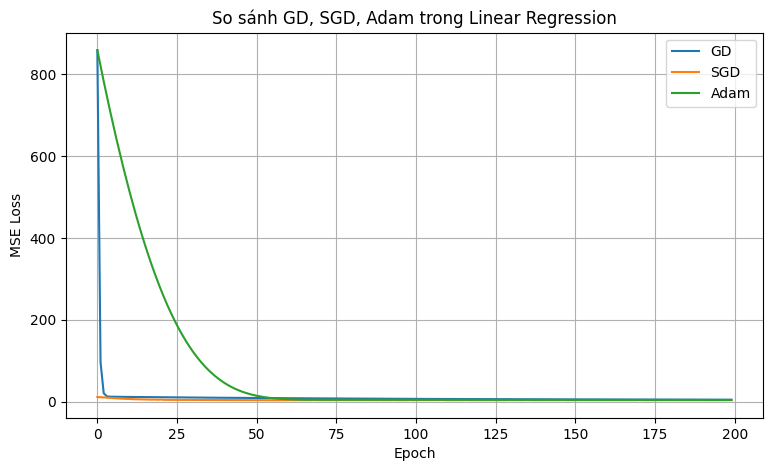

In [16]:
plt.figure(figsize=(9, 5))
plt.plot(losses_gd, label='GD')
plt.plot(losses_sgd, label='SGD')
plt.plot(losses_adam, label='Adam')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('So sánh GD, SGD, Adam trong Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

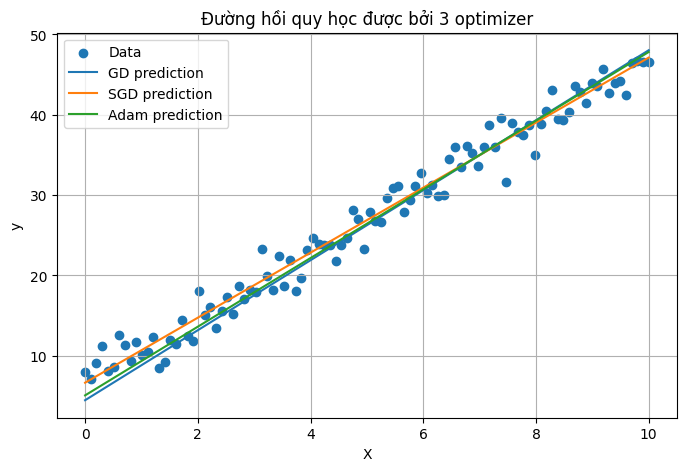

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, w_gd * X + b_gd, label='GD prediction')
plt.plot(X, w_sgd * X + b_sgd, label='SGD prediction')
plt.plot(X, w_adam * X + b_adam, label='Adam prediction')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Đường hồi quy học được bởi 3 optimizer')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
linear_results = pd.DataFrame({
    'Optimizer': ['GD', 'SGD', 'Adam'],
    'w learned': [w_gd, w_sgd, w_adam],
    'b learned': [b_gd, b_sgd, b_adam],
    'Final MSE': [losses_gd[-1], losses_sgd[-1], losses_adam[-1]]
})

linear_results

,Optimizer,w learned,b learned,Final MSE
0,GD,4.356326,4.468026,4.484998
1,SGD,4.046970,6.646224,3.270692
2,Adam,4.274052,5.071782,3.902705


### Giải thích bài tập 4

Dữ liệu thật được tạo từ công thức gần đúng:

$$
y = 4x + 7
$$

Vì có noise nên optimizer không nhất thiết tìm đúng tuyệt đối `w = 4`, `b = 7`, nhưng kết quả nên gần quanh hai giá trị này.

Ý nghĩa:

- `w` là độ dốc của đường dự đoán.
- `b` là điểm cắt trục y.
- MSE càng nhỏ thì đường dự đoán càng gần dữ liệu.

Trong bài này, cả GD, SGD và Adam đều đang cố làm một việc giống nhau: **giảm MSE xuống thấp nhất có thể**.

# Tổng kết cuối tuần 8

Sau bài này, bạn cần nắm được:

1. **Loss function** đo model sai bao nhiêu.
2. **Gradient** cho biết hướng loss tăng nhanh nhất.
3. **Gradient Descent** đi ngược hướng gradient để giảm loss.
4. **SGD** cập nhật nhanh hơn trên dữ liệu lớn nhưng đường đi nhiễu hơn.
5. **Adam** dùng momentum và adaptive learning rate nên thường mạnh trong Deep Learning.

Một câu nhớ nhanh:

> Loss là cái cần giảm. Gradient chỉ hướng đi. Optimizer là người lái xe đưa loss đi xuống.